# PMD2 - Clasificacion de noticias AG News con CRISP-DM

| Campo | Detalle |
|---|---|
| Estudiante | Jhadir Chahua Yupanqui |
| Curso | Mineria de Datos - C64893 |
| Docente | Pilar Rocio Sayan Mejia |
| Periodo | 2026-I |
| Proyecto | PMD2 - Mineria avanzada aplicada a NLP |
| Dataset | `sh0416/ag_news` de Hugging Face |
| Problema | Clasificar noticias en `World`, `Sports`, `Business` y `Sci/Tech` |
| Enfoque | Solo NLP/texto. Se excluye Computer Vision porque AG News no contiene imagenes y esa ruta no califica para este caso. |

Este notebook sigue CRISP-DM de punta a punta: comprension del negocio, comprension de datos, preparacion, modelado, evaluacion y despliegue reproducible.

## Matriz de cumplimiento del PMD2

| Exigencia | Como se cubre en este notebook |
|---|---|
| Semana 9 - Gradient Boosting / XGBoost | Modelo XGBoost sobre embeddings SVD de TF-IDF; si `xgboost` no esta instalado, se usa `HistGradientBoostingClassifier` como fallback reproducible. |
| Semana 10 - Redes Neuronales Artificiales | MLPClassifier y red densa Keras/TensorFlow sobre embeddings densos SVD de texto. |
| Semana 11 - Clustering no supervisado | K-Means/MiniBatch K-Means sobre embeddings, con silueta, ARI, NMI y perfil de clusters contra etiquetas reales. |
| Semana 12 - Naive Bayes | MultinomialNB y ComplementNB con TF-IDF/Bag of Words. |
| Semana 13 - Optimizacion | RandomizedSearchCV/GridSearchCV, validacion estratificada y curvas de aprendizaje para detectar sobreajuste. |
| Semana 14 - Ensamblaje | Voting y Stacking combinando modelos probabilisticos y lineales; comparacion contra modelos individuales. |
| Semana 15 - NLP | Limpieza, tokenizacion, TF-IDF, embeddings densos, analisis de terminos, errores y extension opcional Transformer. |
| Rubrica - Codigo Colab | Markdown narrativo, pipeline reproducible, `random_state`, comparacion robusta, validacion y guardado de artefactos. |
| Rubrica - Reporte ejecutivo | Secciones ejecutivas de problema, resultados, recomendacion, limites y referencias APA 7 al final. |

## Fuentes y alcance

- Dataset: Hugging Face `sh0416/ag_news`, tarea de clasificacion de texto, idioma ingles, formato JSONL.
- Segun la ficha del dataset, AG News usa 120,000 ejemplos de entrenamiento y 7,600 de prueba, con etiquetas 1 a 4.
- Mapeo oficial de clases: `1: World`, `2: Sports`, `3: Business`, `4: Sci/Tech`.
- Restriccion metodologica: se trabaja solo con texto (`title` + `description`). No se usan imagenes, CNN ni pasos de Computer Vision.

Referencia principal del dataset: Zhang, X., Zhao, J., & LeCun, Y. (2015). *Character-level Convolutional Networks for Text Classification*. NeurIPS 28.

# 1. Comprension del negocio

**Contexto empresarial.** Una organizacion de monitoreo de noticias recibe miles de titulares y descripciones breves por dia. La clasificacion manual por categoria editorial consume tiempo, retrasa la publicacion y genera inconsistencias entre analistas.

**Problema de decision.** Asignar automaticamente cada noticia a una de cuatro categorias para priorizar revision humana, enrutar contenido a equipos especializados y medir cobertura informativa por tema.

**Unidad de analisis.** Una noticia, representada por `title` y `description`.

**Variable objetivo.** `label`, con clases `World`, `Sports`, `Business` y `Sci/Tech`.

**Criterios de exito.** Se prioriza `F1 macro` porque las cuatro clases deben rendir de forma equilibrada. Tambien se reportan `accuracy`, `F1 weighted`, matriz de confusion y errores por clase.

**Riesgos y restricciones.** El texto esta en ingles; los modelos pueden confundir noticias de negocios y tecnologia; se evita fuga de informacion usando transformaciones dentro de `Pipeline`; la solucion final debe poder correr en Colab.

# 2. Setup y reproducibilidad

Esta celda fija semillas, rutas, modo de ejecucion y librerias. Para una entrega final en Colab se recomienda dejar `FAST_MODE = False`. Para validar rapidamente en una laptop, se puede ejecutar con la variable de entorno `PMD2_FAST_VALIDATE=1`.

In [1]:
import os
import re
import html
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
    learning_curve,
)
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler, Normalizer
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)
import joblib

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

FAST_MODE = os.getenv("PMD2_FAST_VALIDATE", "0") == "1"
MAX_TRAIN = 8_000 if FAST_MODE else None
MAX_TEST = 2_000 if FAST_MODE else None
MAX_FEATURES = 12_000 if FAST_MODE else 50_000
SVD_COMPONENTS = 60 if FAST_MODE else 250
CV_FOLDS = 2 if FAST_MODE else 3
SEARCH_ITER = 3 if FAST_MODE else 10
N_JOBS = -1

cwd = Path.cwd()
PROJECT_DIR = cwd if cwd.name == "PMD2_AG_News" else cwd / "PMD2_AG_News"
PROJECT_DIR.mkdir(exist_ok=True)
ARTIFACT_DIR = PROJECT_DIR / "artifacts"
CACHE_DIR = ARTIFACT_DIR / "cache"
MODEL_DIR = ARTIFACT_DIR / "models"
FIG_DIR = ARTIFACT_DIR / "figures"
for folder in [CACHE_DIR, MODEL_DIR, FIG_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

LABEL_MAP = {1: "World", 2: "Sports", 3: "Business", 4: "Sci/Tech"}
LABEL_ORDER = [1, 2, 3, 4]
TARGET_NAMES = [LABEL_MAP[i] for i in LABEL_ORDER]

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 120

print(f"FAST_MODE={FAST_MODE}")
print(f"MAX_TRAIN={MAX_TRAIN}, MAX_TEST={MAX_TEST}, MAX_FEATURES={MAX_FEATURES}, SVD_COMPONENTS={SVD_COMPONENTS}")
print(f"Project dir: {PROJECT_DIR.resolve()}")

FAST_MODE=True
MAX_TRAIN=8000, MAX_TEST=2000, MAX_FEATURES=12000, SVD_COMPONENTS=60
Project dir: C:\Users\ASUS\Documents\Codex\2026-06-09\jhadir08-mineria-de-datos-https-github\Mineria-de-Datos\PMD2_AG_News


# 3. Comprension de datos

Se carga AG News desde Hugging Face en formato JSONL. Se mantiene la separacion oficial `train`/`test`; del entrenamiento se separa una validacion estratificada para comparar modelos sin tocar el test final.

In [2]:
TRAIN_URL = "https://huggingface.co/datasets/sh0416/ag_news/resolve/main/train.jsonl"
TEST_URL = "https://huggingface.co/datasets/sh0416/ag_news/resolve/main/test.jsonl"


def load_jsonl_cached(url: str, filename: str) -> pd.DataFrame:
    path = CACHE_DIR / filename
    if path.exists():
        return pd.read_json(path, lines=True)
    df = pd.read_json(url, lines=True)
    df.to_json(path, orient="records", lines=True, force_ascii=False)
    return df


train_raw = load_jsonl_cached(TRAIN_URL, "ag_news_train.jsonl")
test_raw = load_jsonl_cached(TEST_URL, "ag_news_test.jsonl")

print(f"Train oficial: {train_raw.shape[0]:,} filas x {train_raw.shape[1]} columnas")
print(f"Test oficial:  {test_raw.shape[0]:,} filas x {test_raw.shape[1]} columnas")
display(train_raw.head())

Train oficial: 120,000 filas x 3 columnas
Test oficial:  7,600 filas x 3 columnas


,label,title,description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [3]:
def audit_raw_data(df: pd.DataFrame, name: str) -> pd.DataFrame:
    audit = pd.DataFrame({
        "columna": df.columns,
        "tipo": [str(df[c].dtype) for c in df.columns],
        "nulos": [int(df[c].isna().sum()) for c in df.columns],
        "n_unicos": [int(df[c].nunique(dropna=True)) for c in df.columns],
    })
    print(f"\n{name}: {df.shape[0]:,} filas, {df.shape[1]} columnas")
    display(audit)
    print("Distribucion de etiquetas:")
    display(df["label"].value_counts().sort_index().rename(index=LABEL_MAP).to_frame("conteo"))


audit_raw_data(train_raw, "train_raw")
audit_raw_data(test_raw, "test_raw")

for split_name, df in [("train", train_raw), ("test", test_raw)]:
    duplicated_rows = df.duplicated(subset=["title", "description"]).sum()
    invalid_labels = sorted(set(df["label"]) - set(LABEL_MAP))
    print(f"{split_name}: duplicados title+description={duplicated_rows:,}; etiquetas invalidas={invalid_labels}")


train_raw: 120,000 filas, 3 columnas


,columna,tipo,nulos,n_unicos
0,label,int64,0,4
1,title,str,0,114364
2,description,str,0,118731


Distribucion de etiquetas:


,conteo
label,
World,30000
Sports,30000
Business,30000
Sci/Tech,30000



test_raw: 7,600 filas, 3 columnas


,columna,tipo,nulos,n_unicos
0,label,int64,0,4
1,title,str,0,7569
2,description,str,0,7594


Distribucion de etiquetas:


,conteo
label,
World,1900
Sports,1900
Business,1900
Sci/Tech,1900


train: duplicados title+description=0; etiquetas invalidas=[]
test: duplicados title+description=0; etiquetas invalidas=[]


## 3.1 Preparacion inicial de texto para EDA

Se combinan `title` y `description` porque el titulo aporta senales fuertes y la descripcion agrega contexto. La limpieza es conservadora: normaliza HTML y espacios, pero no elimina palabras agresivamente antes de vectorizar.

In [4]:
def clean_text(text: str) -> str:
    text = "" if pd.isna(text) else str(text)
    text = html.unescape(text)
    text = text.replace("\\n", " ")
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def prepare_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["label_name"] = out["label"].map(LABEL_MAP)
    out["title_clean"] = out["title"].map(clean_text)
    out["description_clean"] = out["description"].map(clean_text)
    out["text"] = (out["title_clean"] + ". " + out["description_clean"]).map(clean_text)
    out["text_lower"] = out["text"].str.lower()
    out["chars"] = out["text"].str.len()
    out["words"] = out["text"].str.split().str.len()
    return out


train_all = prepare_dataframe(train_raw)
test_all = prepare_dataframe(test_raw)

display(train_all[["label", "label_name", "title_clean", "description_clean", "chars", "words"]].head())

,label,label_name,title_clean,description_clean,chars,words
0,3,Business,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",145,21
1,3,Business,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,267,36
2,3,Business,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,233,36
3,3,Business,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,257,36
4,3,Business,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...",235,37


In [5]:
def stratified_limit(df: pd.DataFrame, max_rows: int | None, label_col: str = "label") -> pd.DataFrame:
    if max_rows is None or max_rows >= len(df):
        return df.copy().reset_index(drop=True)
    _, sample = train_test_split(
        df,
        test_size=max_rows,
        stratify=df[label_col],
        random_state=RANDOM_STATE,
    )
    return sample.sort_index().reset_index(drop=True)


train_model_all = stratified_limit(train_all, MAX_TRAIN)
test_model = stratified_limit(test_all, MAX_TEST)

train_df, val_df = train_test_split(
    train_model_all,
    test_size=0.20,
    stratify=train_model_all["label"],
    random_state=RANDOM_STATE,
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

def split_summary(name: str, df: pd.DataFrame) -> pd.DataFrame:
    counts = df["label_name"].value_counts().reindex(TARGET_NAMES)
    return pd.DataFrame({
        "split": name,
        "filas": len(df),
        "clase": counts.index,
        "conteo": counts.values,
        "porcentaje": (counts.values / len(df) * 100).round(2),
    })

split_table = pd.concat([
    split_summary("train", train_df),
    split_summary("validation", val_df),
    split_summary("test", test_model),
], ignore_index=True)
display(split_table)

print(f"Tamano usado para modelado: train={len(train_df):,}, validation={len(val_df):,}, test={len(test_model):,}")

,split,filas,clase,conteo,porcentaje
0,train,6400,World,1600,25.0
1,train,6400,Sports,1600,25.0
2,train,6400,Business,1600,25.0
3,train,6400,Sci/Tech,1600,25.0
4,validation,1600,World,400,25.0
5,validation,1600,Sports,400,25.0
6,validation,1600,Business,400,25.0
7,validation,1600,Sci/Tech,400,25.0
8,test,2000,World,500,25.0
9,test,2000,Sports,500,25.0


Tamano usado para modelado: train=6,400, validation=1,600, test=2,000


## 3.2 EDA: distribucion, longitud y ejemplos

La EDA verifica que el problema sea multiclase balanceado, que no falten textos y que las longitudes sean razonables para modelos de bolsa de palabras, TF-IDF y embeddings densos.

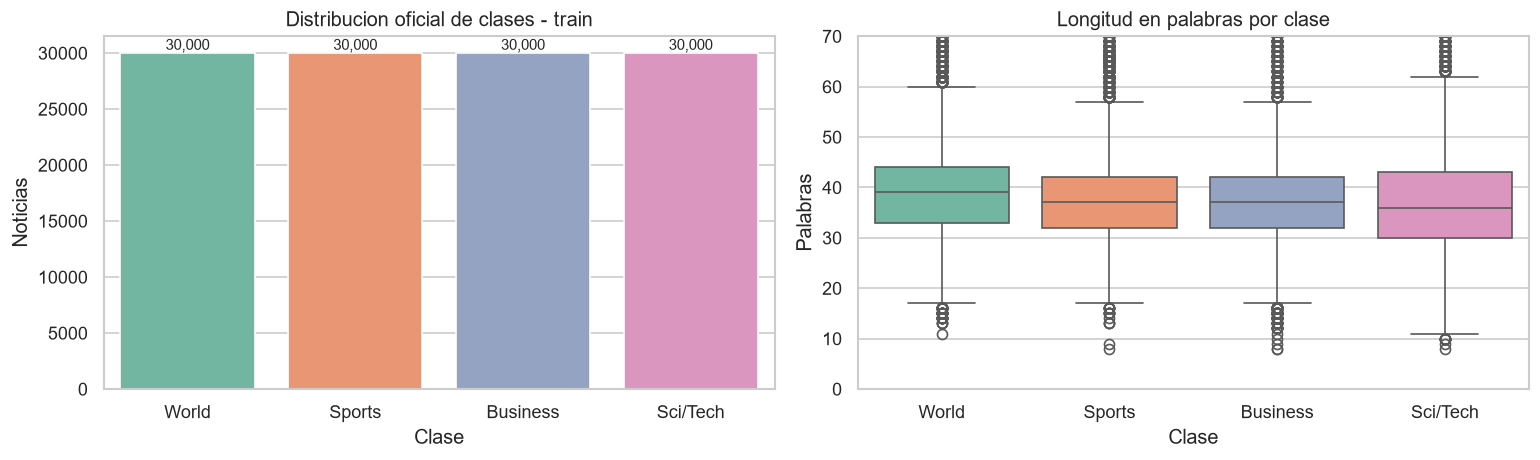

chars                  words                
             mean median  min  max  mean median min  max
label_name                                              
Business    240.5  236.0  101  960  37.5   37.0   8  134
Sci/Tech    236.9  231.0   81  977  37.2   36.0   8  177
Sports      225.0  220.0   84  836  37.8   37.0   8  151
World       242.6  243.0   88  859  38.9   39.0  11  145

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

class_counts = train_all["label_name"].value_counts().reindex(TARGET_NAMES)
sns.barplot(x=class_counts.index, y=class_counts.values, ax=axes[0], palette="Set2")
axes[0].set_title("Distribucion oficial de clases - train")
axes[0].set_xlabel("Clase")
axes[0].set_ylabel("Noticias")
for idx, value in enumerate(class_counts.values):
    axes[0].text(idx, value, f"{value:,}", ha="center", va="bottom", fontsize=9)

sns.boxplot(data=train_all, x="label_name", y="words", order=TARGET_NAMES, ax=axes[1], palette="Set2")
axes[1].set_title("Longitud en palabras por clase")
axes[1].set_xlabel("Clase")
axes[1].set_ylabel("Palabras")
axes[1].set_ylim(0, train_all["words"].quantile(0.99))

plt.tight_layout()
plt.show()

length_summary = train_all.groupby("label_name")[["chars", "words"]].agg(["mean", "median", "min", "max"]).round(1)
display(length_summary)

In [7]:
examples = pd.concat(
    [group.sample(2, random_state=RANDOM_STATE) for _, group in train_all.groupby("label_name")],
    ignore_index=True,
)[["label_name", "title_clean", "description_clean"]]
display(examples)

,label_name,title_clean,description_clean
0,Business,US house sales fall in July,Sales of non-new houses in the US fell last mo...
1,Business,DJ to acquire MarketWatch,"Dow Jones amp; Co., publisher of the Wall Stre..."
2,Sci/Tech,Gartner optimistic about chip numbers,But that optimism isn #39;t matched by Infineo...
3,Sci/Tech,Fossil Indicates Brown Bears Went South,"CALGARY, Alberta - A fossilized jaw found in a..."
4,Sports,Second Andre win in a row boosts US gold medal...,"Andre Dirrell, fighting with a tattoo of his g..."
5,Sports,NFL Game Summary - Kansas City at New Orleans,Tight end Tony Gonzalez caught six passes for ...
6,World,Explosion Rocks Baghdad Neighborhood,"BAGHDAD, Iraq, August 24 -- A car bomb explode..."
7,World,BBC reporters' log,BBC correspondents record events in the Middle...


## 3.3 EDA textual: terminos representativos por clase

Se usa TF-IDF solamente para entender senales semanticas. Esta transformacion exploratoria no entrena modelos y no toca el test.

In [8]:
eda_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5 if not FAST_MODE else 2,
    max_df=0.90,
    max_features=min(MAX_FEATURES, 20_000),
    sublinear_tf=True,
)
X_eda = eda_vectorizer.fit_transform(train_df["text_lower"])
terms = np.array(eda_vectorizer.get_feature_names_out())

rows = []
for label, label_name in LABEL_MAP.items():
    mask = train_df["label"].to_numpy() == label
    mean_tfidf = np.asarray(X_eda[mask].mean(axis=0)).ravel()
    top_idx = mean_tfidf.argsort()[-12:][::-1]
    rows.append({
        "clase": label_name,
        "top_terminos_tfidf": ", ".join(terms[top_idx]),
    })

display(pd.DataFrame(rows))

,clase,top_terminos_tfidf
0,World,"iraq, said, ap, president, 39, reuters, killed..."
1,Sports,"39, ap, season, game, team, win, league, cup, ..."
2,Business,"39, oil, reuters, said, prices, new, stocks, c..."
3,Sci/Tech,"microsoft, new, 39, software, internet, space,..."


# 4. Preparacion de datos

La preparacion queda encapsulada en `Pipeline` de scikit-learn para evitar fuga de informacion: el vectorizador y las transformaciones se ajustan solo con entrenamiento en cada modelo o validacion cruzada.

Estrategia:

- Entrada: `text_lower`, texto combinado de titulo y descripcion.
- Target: `label` numerico oficial, conservando el mapeo a nombres de clase.
- Split: train/validation/test estratificados.
- Features: TF-IDF de palabras y bigramas; embeddings densos por `TruncatedSVD` para boosting, MLP y clustering.

In [9]:
X_train = train_df["text_lower"]
y_train = train_df["label"]
X_val = val_df["text_lower"]
y_val = val_df["label"]
X_test = test_model["text_lower"]
y_test = test_model["label"]

base_tfidf = dict(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2 if FAST_MODE else 3,
    max_df=0.90,
    max_features=MAX_FEATURES,
    sublinear_tf=True,
)

base_count = dict(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2 if FAST_MODE else 3,
    max_df=0.90,
    max_features=MAX_FEATURES,
)

print("Validacion de preparacion:")
print(f"- X_train: {len(X_train):,} textos")
print(f"- X_val:   {len(X_val):,} textos")
print(f"- X_test:  {len(X_test):,} textos")
print(f"- Labels:  {sorted(y_train.unique())} -> {TARGET_NAMES}")

Validacion de preparacion:
- X_train: 6,400 textos
- X_val:   1,600 textos
- X_test:  2,000 textos
- Labels:  [np.int64(1), np.int64(2), np.int64(3), np.int64(4)] -> ['World', 'Sports', 'Business', 'Sci/Tech']


# 5. Modelado - Baselines y modelos individuales

La comparacion usa siempre la misma validacion. Se inicia con un baseline ingenuo y luego se agregan modelos de complejidad creciente.

In [10]:
results = []
fitted_models = {}
validation_predictions = {}


def safe_predict_proba(model, X):
    if hasattr(model, "predict_proba"):
        try:
            proba = model.predict_proba(X)
            if proba is not None and proba.shape[1] == len(LABEL_ORDER):
                return proba
        except Exception:
            return None
    return None


def evaluate_model(name: str, model, notes: str = "", fit: bool = True):
    start = time.time()
    if fit:
        model.fit(X_train, y_train)
    fit_seconds = time.time() - start

    y_pred = model.predict(X_val)
    proba = safe_predict_proba(model, X_val)

    row = {
        "modelo": name,
        "accuracy_val": accuracy_score(y_val, y_pred),
        "f1_macro_val": f1_score(y_val, y_pred, average="macro"),
        "f1_weighted_val": f1_score(y_val, y_pred, average="weighted"),
        "precision_macro_val": precision_score(y_val, y_pred, average="macro", zero_division=0),
        "recall_macro_val": recall_score(y_val, y_pred, average="macro", zero_division=0),
        "roc_auc_ovr_macro_val": np.nan,
        "fit_seconds": fit_seconds,
        "notas": notes,
    }
    if proba is not None:
        try:
            row["roc_auc_ovr_macro_val"] = roc_auc_score(y_val, proba, multi_class="ovr", average="macro", labels=LABEL_ORDER)
        except Exception:
            pass

    results.append(row)
    fitted_models[name] = model
    validation_predictions[name] = y_pred
    print(f"{name}: F1 macro={row['f1_macro_val']:.4f}, accuracy={row['accuracy_val']:.4f}, tiempo={fit_seconds:.1f}s")
    return row


def make_tfidf_nb(alpha=0.5):
    return Pipeline([
        ("tfidf", TfidfVectorizer(**base_tfidf)),
        ("clf", MultinomialNB(alpha=alpha)),
    ])


def make_count_nb(alpha=0.5):
    return Pipeline([
        ("bow", CountVectorizer(**base_count)),
        ("clf", MultinomialNB(alpha=alpha)),
    ])


def make_logreg(C=2.0):
    return Pipeline([
        ("tfidf", TfidfVectorizer(**base_tfidf)),
        ("clf", LogisticRegression(C=C, max_iter=1_000, n_jobs=N_JOBS, random_state=RANDOM_STATE)),
    ])


def make_sgd_log(alpha=1e-5):
    return Pipeline([
        ("tfidf", TfidfVectorizer(**base_tfidf)),
        ("clf", SGDClassifier(loss="log_loss", alpha=alpha, max_iter=1_000, random_state=RANDOM_STATE, n_jobs=N_JOBS)),
    ])


def make_svd_steps(n_components=None):
    n_components = n_components or SVD_COMPONENTS
    return [
        ("tfidf", TfidfVectorizer(**base_tfidf)),
        ("svd", TruncatedSVD(n_components=n_components, random_state=RANDOM_STATE)),
        ("scaler", StandardScaler()),
    ]

In [11]:
baseline_models = {
    "Baseline ingenuo - clase mayoritaria": DummyClassifier(strategy="most_frequent"),
    "Semana 12 - MultinomialNB Bag of Words": make_count_nb(alpha=0.5),
    "Semana 12 - MultinomialNB TF-IDF": make_tfidf_nb(alpha=0.5),
    "Semana 12 - ComplementNB TF-IDF": Pipeline([
        ("tfidf", TfidfVectorizer(**base_tfidf)),
        ("clf", ComplementNB(alpha=0.5)),
    ]),
    "Modelo lineal - Logistic Regression TF-IDF": make_logreg(C=2.0),
    "Modelo lineal - LinearSVC TF-IDF": Pipeline([
        ("tfidf", TfidfVectorizer(**base_tfidf)),
        ("clf", LinearSVC(C=1.0, random_state=RANDOM_STATE)),
    ]),
}

for name, model in baseline_models.items():
    evaluate_model(name, model, notes="baseline/comparacion inicial")

pd.DataFrame(results).sort_values("f1_macro_val", ascending=False)

Baseline ingenuo - clase mayoritaria: F1 macro=0.1000, accuracy=0.2500, tiempo=0.0s


Semana 12 - MultinomialNB Bag of Words: F1 macro=0.8852, accuracy=0.8856, tiempo=0.5s


Semana 12 - MultinomialNB TF-IDF: F1 macro=0.8839, accuracy=0.8844, tiempo=0.5s


Semana 12 - ComplementNB TF-IDF: F1 macro=0.8938, accuracy=0.8944, tiempo=0.4s


Modelo lineal - Logistic Regression TF-IDF: F1 macro=0.8903, accuracy=0.8906, tiempo=0.8s


Modelo lineal - LinearSVC TF-IDF: F1 macro=0.8877, accuracy=0.8881, tiempo=0.5s


,modelo,accuracy_val,f1_macro_val,f1_weighted_val,precision_macro_val,recall_macro_val,roc_auc_ovr_macro_val,fit_seconds,notas
3,Semana 12 - ComplementNB TF-IDF,0.894375,0.893756,0.893756,0.893940,0.894375,0.973367,0.436666,baseline/comparacion inicial
4,Modelo lineal - Logistic Regression TF-IDF,0.890625,0.890261,0.890261,0.890229,0.890625,0.973856,0.837930,baseline/comparacion inicial
5,Modelo lineal - LinearSVC TF-IDF,0.888125,0.887722,0.887722,0.887594,0.888125,NaN,0.494716,baseline/comparacion inicial
1,Semana 12 - MultinomialNB Bag of Words,0.885625,0.885153,0.885153,0.885591,0.885625,0.972147,0.526518,baseline/comparacion inicial
2,Semana 12 - MultinomialNB TF-IDF,0.884375,0.883881,0.883881,0.884030,0.884375,0.973554,0.540612,baseline/comparacion inicial
0,Baseline ingenuo - clase mayoritaria,0.250000,0.100000,0.100000,0.062500,0.250000,0.500000,0.000000,baseline/comparacion inicial


## 5.1 Semana 9 - Gradient Boosting / XGBoost

Para texto se transforma TF-IDF a un espacio denso con SVD. Si `xgboost` esta disponible, se entrena XGBoost multiclase. Si no esta instalado, se usa `HistGradientBoostingClassifier` para mantener la ejecucion completa y comparable.

In [12]:
def make_boosting_pipeline():
    try:
        from xgboost import XGBClassifier

        class ZeroBasedXGBClassifier(BaseEstimator, ClassifierMixin):
            def __init__(self, n_estimators=300, max_depth=4, learning_rate=0.08, subsample=0.90, colsample_bytree=0.90):
                self.n_estimators = n_estimators
                self.max_depth = max_depth
                self.learning_rate = learning_rate
                self.subsample = subsample
                self.colsample_bytree = colsample_bytree

            def fit(self, X, y):
                self.classes_ = np.array(sorted(pd.unique(y)))
                self.class_to_zero_ = {label: idx for idx, label in enumerate(self.classes_)}
                y_zero = np.array([self.class_to_zero_[label] for label in y])
                self.model_ = XGBClassifier(
                    n_estimators=self.n_estimators,
                    max_depth=self.max_depth,
                    learning_rate=self.learning_rate,
                    subsample=self.subsample,
                    colsample_bytree=self.colsample_bytree,
                    objective="multi:softprob",
                    num_class=len(self.classes_),
                    eval_metric="mlogloss",
                    tree_method="hist",
                    random_state=RANDOM_STATE,
                    n_jobs=N_JOBS,
                )
                self.model_.fit(X, y_zero)
                return self

            def predict(self, X):
                pred_zero = self.model_.predict(X).astype(int)
                return self.classes_[pred_zero]

            def predict_proba(self, X):
                return self.model_.predict_proba(X)

        clf = ZeroBasedXGBClassifier(
            n_estimators=80 if FAST_MODE else 300,
            max_depth=4,
            learning_rate=0.08,
            subsample=0.90,
            colsample_bytree=0.90,
        )
        model_name = "Semana 9 - XGBoost sobre embeddings SVD(TF-IDF)"
        notes = "xgboost instalado"
    except Exception as exc:
        clf = HistGradientBoostingClassifier(
            max_iter=50 if FAST_MODE else 180,
            learning_rate=0.08,
            l2_regularization=0.10,
            random_state=RANDOM_STATE,
        )
        model_name = "Semana 9 - HistGradientBoosting fallback sobre SVD(TF-IDF)"
        notes = f"fallback porque xgboost no esta disponible: {type(exc).__name__}"

    pipe = Pipeline(make_svd_steps() + [("clf", clf)])
    return model_name, pipe, notes


boost_name, boost_pipe, boost_notes = make_boosting_pipeline()
evaluate_model(boost_name, boost_pipe, notes=boost_notes)

Semana 9 - XGBoost sobre embeddings SVD(TF-IDF): F1 macro=0.8415, accuracy=0.8419, tiempo=1.6s


{'modelo': 'Semana 9 - XGBoost sobre embeddings SVD(TF-IDF)',
 'accuracy_val': 0.841875,
 'f1_macro_val': 0.8414604622019894,
 'f1_weighted_val': 0.8414604622019894,
 'precision_macro_val': 0.8416351445763802,
 'recall_macro_val': 0.841875,
 'roc_auc_ovr_macro_val': 0.9591151041666667,
 'fit_seconds': 1.6325712203979492,
 'notas': 'xgboost instalado'}

## 5.2 Semana 10 - Red neuronal artificial

Se usa un MLP sobre embeddings densos SVD. La red neuronal no recibe texto crudo: primero se vectoriza, se reduce dimensionalidad y se escalan las variables latentes. En un entorno con TensorFlow disponible tambien se entrena una red densa Keras para cubrir explicitamente la ruta de redes neuronales con backpropagation/Adam.

In [13]:
mlp_pipe = Pipeline(make_svd_steps() + [
    ("clf", MLPClassifier(
        hidden_layer_sizes=(96, 48) if FAST_MODE else (160, 80),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        batch_size=128,
        learning_rate_init=1e-3,
        max_iter=12 if FAST_MODE else 30,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=4,
        random_state=RANDOM_STATE,
    )),
])

evaluate_model("Semana 10 - MLP sobre embeddings SVD(TF-IDF)", mlp_pipe, notes="red neuronal densa para NLP")

Semana 10 - MLP sobre embeddings SVD(TF-IDF): F1 macro=0.8576, accuracy=0.8581, tiempo=1.3s


{'modelo': 'Semana 10 - MLP sobre embeddings SVD(TF-IDF)',
 'accuracy_val': 0.858125,
 'f1_macro_val': 0.8576041793923636,
 'f1_weighted_val': 0.8576041793923637,
 'precision_macro_val': 0.858131372399668,
 'recall_macro_val': 0.858125,
 'roc_auc_ovr_macro_val': 0.9639432291666666,
 'fit_seconds': 1.2689192295074463,
 'notas': 'red neuronal densa para NLP'}

## 5.3 Semana 10 - Red neuronal con Keras/TensorFlow

Esta celda entrena una red densa en TensorFlow/Keras cuando la dependencia esta instalada. Usa la misma representacion densa SVD para mantener comparabilidad con el MLP de scikit-learn y evitar entrenar una red directamente sobre matrices TF-IDF dispersas.

In [14]:
try:
    import tensorflow as tf
    from tensorflow import keras

    tf.random.set_seed(RANDOM_STATE)

    keras_vectorizer = TfidfVectorizer(**base_tfidf)
    X_train_tfidf_keras = keras_vectorizer.fit_transform(X_train)
    X_val_tfidf_keras = keras_vectorizer.transform(X_val)

    keras_svd = TruncatedSVD(n_components=SVD_COMPONENTS, random_state=RANDOM_STATE)
    X_train_svd_keras = keras_svd.fit_transform(X_train_tfidf_keras)
    X_val_svd_keras = keras_svd.transform(X_val_tfidf_keras)

    keras_scaler = StandardScaler()
    X_train_keras = keras_scaler.fit_transform(X_train_svd_keras).astype("float32")
    X_val_keras = keras_scaler.transform(X_val_svd_keras).astype("float32")

    y_train_keras = (y_train.to_numpy() - 1).astype("int32")
    y_val_keras = (y_val.to_numpy() - 1).astype("int32")

    keras_model = keras.Sequential([
        keras.layers.Input(shape=(X_train_keras.shape[1],)),
        keras.layers.Dense(128 if not FAST_MODE else 64, activation="relu"),
        keras.layers.Dropout(0.25),
        keras.layers.Dense(64 if not FAST_MODE else 32, activation="relu"),
        keras.layers.Dense(len(LABEL_ORDER), activation="softmax"),
    ])
    keras_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    start = time.time()
    history = keras_model.fit(
        X_train_keras,
        y_train_keras,
        validation_data=(X_val_keras, y_val_keras),
        epochs=4 if FAST_MODE else 8,
        batch_size=128,
        verbose=0,
        callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)],
    )
    fit_seconds = time.time() - start

    keras_proba = keras_model.predict(X_val_keras, verbose=0)
    keras_pred = keras_proba.argmax(axis=1) + 1
    keras_row = {
        "modelo": "Semana 10 - Keras/TensorFlow red densa sobre SVD(TF-IDF)",
        "accuracy_val": accuracy_score(y_val, keras_pred),
        "f1_macro_val": f1_score(y_val, keras_pred, average="macro"),
        "f1_weighted_val": f1_score(y_val, keras_pred, average="weighted"),
        "precision_macro_val": precision_score(y_val, keras_pred, average="macro", zero_division=0),
        "recall_macro_val": recall_score(y_val, keras_pred, average="macro", zero_division=0),
        "roc_auc_ovr_macro_val": roc_auc_score(y_val, keras_proba, multi_class="ovr", average="macro", labels=LABEL_ORDER),
        "fit_seconds": fit_seconds,
        "notas": "red neuronal Keras/TensorFlow con Adam",
    }
    results.append(keras_row)
    validation_predictions[keras_row["modelo"]] = keras_pred
    print(f"{keras_row['modelo']}: F1 macro={keras_row['f1_macro_val']:.4f}, accuracy={keras_row['accuracy_val']:.4f}, tiempo={fit_seconds:.1f}s")
except Exception as exc:
    print(f"Keras/TensorFlow no se ejecuto en este entorno: {type(exc).__name__}: {exc}")

Semana 10 - Keras/TensorFlow red densa sobre SVD(TF-IDF): F1 macro=0.8487, accuracy=0.8494, tiempo=1.4s


# 6. Semana 11 - Clustering no supervisado

El clustering no usa las etiquetas para entrenar. Las etiquetas solo se usan despues para interpretar si los grupos descubiertos se alinean con las categorias reales.

In [15]:
cluster_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2 if FAST_MODE else 5,
    max_df=0.90,
    max_features=10_000 if FAST_MODE else 30_000,
    sublinear_tf=True,
)
X_cluster_tfidf = cluster_vectorizer.fit_transform(train_df["text_lower"])
cluster_svd = TruncatedSVD(n_components=50 if FAST_MODE else 120, random_state=RANDOM_STATE)
X_cluster_raw = cluster_svd.fit_transform(X_cluster_tfidf)
X_cluster = Normalizer().fit_transform(X_cluster_raw)

cluster_rows = []
for k in [4, 6, 8]:
    km = MiniBatchKMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10, batch_size=1_024)
    cluster_labels = km.fit_predict(X_cluster)
    sample_size = min(3_000, len(X_cluster) - 1)
    sil = silhouette_score(X_cluster, cluster_labels, sample_size=sample_size, random_state=RANDOM_STATE)
    cluster_rows.append({
        "k": k,
        "silhouette": sil,
        "ARI_vs_label_real": adjusted_rand_score(y_train, cluster_labels),
        "NMI_vs_label_real": normalized_mutual_info_score(y_train, cluster_labels),
        "modelo": km,
        "labels": cluster_labels,
    })

cluster_eval = pd.DataFrame([{c: r[c] for c in ["k", "silhouette", "ARI_vs_label_real", "NMI_vs_label_real"]} for r in cluster_rows])
display(cluster_eval.sort_values("silhouette", ascending=False))

best_cluster_info = max(cluster_rows, key=lambda r: r["silhouette"])
best_kmeans = best_cluster_info["modelo"]
best_cluster_labels = best_cluster_info["labels"]
train_df = train_df.copy()
train_df["cluster"] = best_cluster_labels

print(f"Mejor k por silueta: {best_cluster_info['k']}")
display(pd.crosstab(train_df["cluster"], train_df["label_name"], normalize="index").round(3))

,k,silhouette,ARI_vs_label_real,NMI_vs_label_real
2,8,0.075418,0.312939,0.347001
1,6,0.071086,0.395160,0.388773
0,4,0.048047,0.314095,0.340738


Mejor k por silueta: 8


label_name,Business,Sci/Tech,Sports,World
cluster,,,,
0,0.733,0.136,0.078,0.053
1,0.039,0.236,0.373,0.352
2,0.042,0.073,0.849,0.036
3,0.110,0.869,0.005,0.016
4,0.726,0.143,0.078,0.052
5,0.045,0.029,0.119,0.807
6,0.180,0.139,0.140,0.540
7,0.021,0.263,0.036,0.680


In [16]:
cluster_terms = np.array(cluster_vectorizer.get_feature_names_out())
approx_term_centers = best_kmeans.cluster_centers_ @ cluster_svd.components_
cluster_profiles = []
for cluster_id in range(best_kmeans.n_clusters):
    top_idx = approx_term_centers[cluster_id].argsort()[-10:][::-1]
    dominant_class = train_df.loc[train_df["cluster"] == cluster_id, "label_name"].mode().iloc[0]
    cluster_profiles.append({
        "cluster": cluster_id,
        "clase_dominante": dominant_class,
        "top_terminos": ", ".join(cluster_terms[top_idx]),
        "n_noticias": int((train_df["cluster"] == cluster_id).sum()),
    })

display(pd.DataFrame(cluster_profiles).sort_values("cluster"))

,cluster,clase_dominante,top_terminos,n_noticias
0,0,Business,"reuters, new, oil, york, new york, prices, sto...",818
1,1,Sports,"ap, ap ap, 151, new, friday, said, wednesday, ...",415
2,2,Sports,"39, season, game, team, win, league, year, nig...",1295
3,3,Sci/Tech,"microsoft, 39, new, software, music, ibm, inte...",994
4,4,Business,"39, company, said, million, corp, billion, chi...",844
5,5,World,"iraq, minister, prime, india, prime minister, ...",445
6,6,World,"quot, president, bush, 39, united, afp, court,...",970
7,7,World,"people, killed, space, reuters, said, police, ...",619


# 7. Semana 13 - Optimizacion y curvas de aprendizaje

Se optimiza un modelo lineal fuerte porque suele ser competitivo en NLP con TF-IDF. La busqueda se hace con validacion cruzada estratificada y `F1 macro`.

In [17]:
search_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(lowercase=True, stop_words="english", sublinear_tf=True)),
    ("clf", LogisticRegression(max_iter=1_000, n_jobs=N_JOBS, random_state=RANDOM_STATE)),
])

param_dist = {
    "tfidf__max_features": [12_000, 25_000] if FAST_MODE else [20_000, 35_000, 50_000, 70_000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [2, 3, 5],
    "tfidf__max_df": [0.85, 0.90, 0.95],
    "clf__C": [0.5, 1.0, 2.0, 4.0],
}

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
random_search = RandomizedSearchCV(
    search_pipe,
    param_distributions=param_dist,
    n_iter=SEARCH_ITER,
    scoring="f1_macro",
    cv=cv,
    n_jobs=N_JOBS,
    random_state=RANDOM_STATE,
    verbose=1,
)

random_search.fit(X_train, y_train)
print(f"Mejor F1 macro CV: {random_search.best_score_:.4f}")
print("Mejores parametros:")
print(json.dumps(random_search.best_params_, indent=2))

evaluate_model("Semana 13 - Logistic Regression optimizada RandomizedSearchCV", random_search.best_estimator_, notes="modelo optimizado", fit=False)

Fitting 2 folds for each of 3 candidates, totalling 6 fits


Mejor F1 macro CV: 0.8787
Mejores parametros:
{
  "tfidf__ngram_range": [
    1,
    2
  ],
  "tfidf__min_df": 3,
  "tfidf__max_features": 25000,
  "tfidf__max_df": 0.85,
  "clf__C": 4.0
}
Semana 13 - Logistic Regression optimizada RandomizedSearchCV: F1 macro=0.8904, accuracy=0.8906, tiempo=0.0s


{'modelo': 'Semana 13 - Logistic Regression optimizada RandomizedSearchCV',
 'accuracy_val': 0.890625,
 'f1_macro_val': 0.8903804584042943,
 'f1_weighted_val': 0.8903804584042941,
 'precision_macro_val': 0.8902703521422699,
 'recall_macro_val': 0.890625,
 'roc_auc_ovr_macro_val': 0.9734984375000001,
 'fit_seconds': 0.0,
 'notas': 'modelo optimizado'}

,train_size,f1_train_mean,f1_train_std,f1_cv_mean,f1_cv_std
0,1000,0.9975,0.0005,0.8311,0.0002
1,2000,0.9958,0.0007,0.8577,0.0026
2,3000,0.9943,0.0013,0.8744,0.0010
3,4000,0.9927,0.0003,0.8821,0.0005


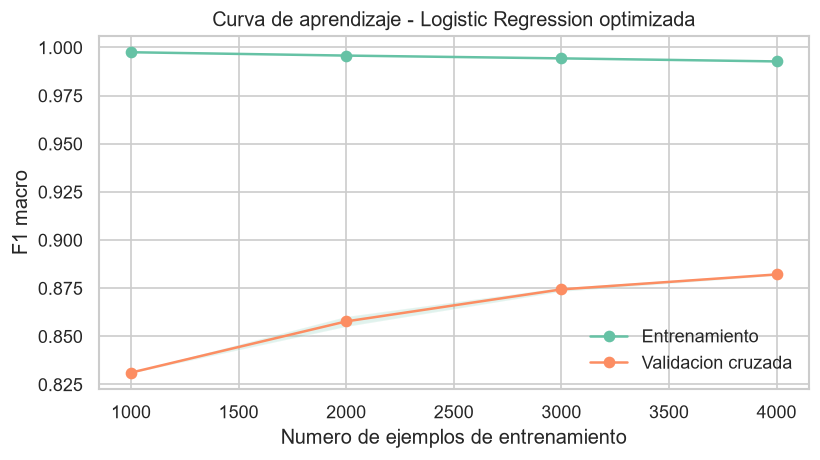

In [18]:
learning_estimator = clone(random_search.best_estimator_)
train_sizes = np.linspace(0.25, 1.0, 4 if FAST_MODE else 5)
X_curve = pd.concat([X_train, X_val], ignore_index=True)
y_curve = pd.concat([y_train, y_val], ignore_index=True)

sizes, train_scores, cv_scores = learning_curve(
    learning_estimator,
    X_curve,
    y_curve,
    train_sizes=train_sizes,
    cv=cv,
    scoring="f1_macro",
    n_jobs=N_JOBS,
)

curve_df = pd.DataFrame({
    "train_size": sizes,
    "f1_train_mean": train_scores.mean(axis=1),
    "f1_train_std": train_scores.std(axis=1),
    "f1_cv_mean": cv_scores.mean(axis=1),
    "f1_cv_std": cv_scores.std(axis=1),
})
display(curve_df.round(4))

plt.figure(figsize=(7, 4))
plt.plot(curve_df["train_size"], curve_df["f1_train_mean"], marker="o", label="Entrenamiento")
plt.plot(curve_df["train_size"], curve_df["f1_cv_mean"], marker="o", label="Validacion cruzada")
plt.fill_between(curve_df["train_size"], curve_df["f1_cv_mean"] - curve_df["f1_cv_std"], curve_df["f1_cv_mean"] + curve_df["f1_cv_std"], alpha=0.2)
plt.title("Curva de aprendizaje - Logistic Regression optimizada")
plt.xlabel("Numero de ejemplos de entrenamiento")
plt.ylabel("F1 macro")
plt.legend()
plt.tight_layout()
plt.show()

# 8. Semana 14 - Ensamblaje

Se comparan dos estrategias:

- `VotingClassifier`: combina predicciones probabilisticas de modelos distintos.
- `StackingClassifier`: usa predicciones de modelos base como entradas de un meta-modelo logistico.

El objetivo es verificar si la combinacion mejora o estabiliza el desempeno frente al mejor modelo individual.

In [19]:
soft_voting = VotingClassifier(
    estimators=[
        ("nb", make_tfidf_nb(alpha=0.5)),
        ("logreg", make_logreg(C=random_search.best_params_.get("clf__C", 2.0))),
        ("sgd_log", make_sgd_log(alpha=1e-5)),
    ],
    voting="soft",
    n_jobs=N_JOBS,
)

evaluate_model("Semana 14 - Voting soft NB + LogReg + SGD", soft_voting, notes="ensamblaje soft voting")

stacking = StackingClassifier(
    estimators=[
        ("nb", make_tfidf_nb(alpha=0.5)),
        ("logreg", make_logreg(C=random_search.best_params_.get("clf__C", 2.0))),
        ("sgd_log", make_sgd_log(alpha=1e-5),
        ),
    ],
    final_estimator=LogisticRegression(max_iter=1_000, random_state=RANDOM_STATE),
    stack_method="predict_proba",
    cv=CV_FOLDS,
    n_jobs=N_JOBS,
)

evaluate_model("Semana 14 - Stacking NB + LogReg + SGD", stacking, notes="ensamblaje stacking")

Semana 14 - Voting soft NB + LogReg + SGD: F1 macro=0.8921, accuracy=0.8925, tiempo=0.9s


Semana 14 - Stacking NB + LogReg + SGD: F1 macro=0.8910, accuracy=0.8912, tiempo=2.1s


{'modelo': 'Semana 14 - Stacking NB + LogReg + SGD',
 'accuracy_val': 0.89125,
 'f1_macro_val': 0.8909718975045609,
 'f1_weighted_val': 0.890971897504561,
 'precision_macro_val': 0.8911893112066132,
 'recall_macro_val': 0.8912499999999999,
 'roc_auc_ovr_macro_val': 0.9758322916666667,
 'fit_seconds': 2.1374080181121826,
 'notas': 'ensamblaje stacking'}

# 9. Semana 15 - Pipeline NLP completo y extension Transformer

El pipeline principal cubre limpieza, tokenizacion, TF-IDF, embeddings densos SVD, modelos clasicos, red neuronal, optimizacion, ensamble y analisis de errores.

La ruta Transformer se deja como extension opcional por costo computacional. Para activarla en Colab, instalar `transformers` y ejecutar con `RUN_TRANSFORMER=True`. No se activa por defecto para que la ejecucion completa del notebook sea estable en CPU.

In [20]:
RUN_TRANSFORMER = False

if RUN_TRANSFORMER:
    try:
        import torch
        from transformers import AutoTokenizer, AutoModel
        print("Transformer disponible. Ejecutar aqui una extraccion de embeddings DistilBERT sobre una muestra controlada.")
        print("Sugerencia: usar distilbert-base-uncased, mean pooling y LogisticRegression sobre embeddings.")
    except Exception as exc:
        print(f"No se pudo activar Transformer: {type(exc).__name__}: {exc}")
else:
    print("Transformer documentado como extension opcional. El modelo avanzado ejecutado en este notebook es MLP sobre embeddings SVD.")

Transformer documentado como extension opcional. El modelo avanzado ejecutado en este notebook es MLP sobre embeddings SVD.


# 10. Evaluacion comparativa

Se ordenan todos los modelos por `F1 macro` en validacion. Luego se toma el mejor modelo y se evalua una sola vez sobre el test oficial o el subconjunto de test configurado.

In [21]:
results_df = pd.DataFrame(results).sort_values("f1_macro_val", ascending=False).reset_index(drop=True)
display(results_df.style.format({
    "accuracy_val": "{:.4f}",
    "f1_macro_val": "{:.4f}",
    "f1_weighted_val": "{:.4f}",
    "precision_macro_val": "{:.4f}",
    "recall_macro_val": "{:.4f}",
    "roc_auc_ovr_macro_val": "{:.4f}",
    "fit_seconds": "{:.1f}",
}))

best_name = results_df.loc[0, "modelo"]
best_model = fitted_models[best_name]
print(f"Mejor modelo por validacion: {best_name}")

,modelo,accuracy_val,f1_macro_val,f1_weighted_val,precision_macro_val,recall_macro_val,roc_auc_ovr_macro_val,fit_seconds,notas
0,Semana 12 - ComplementNB TF-IDF,0.8944,0.8938,0.8938,0.8939,0.8944,0.9734,0.4,baseline/comparacion inicial
1,Semana 14 - Voting soft NB + LogReg + SGD,0.8925,0.8921,0.8921,0.8920,0.8925,0.9756,0.9,ensamblaje soft voting
2,Semana 14 - Stacking NB + LogReg + SGD,0.8912,0.8910,0.8910,0.8912,0.8912,0.9758,2.1,ensamblaje stacking
3,Semana 13 - Logistic Regression optimizada RandomizedSearchCV,0.8906,0.8904,0.8904,0.8903,0.8906,0.9735,0.0,modelo optimizado
4,Modelo lineal - Logistic Regression TF-IDF,0.8906,0.8903,0.8903,0.8902,0.8906,0.9739,0.8,baseline/comparacion inicial
5,Modelo lineal - LinearSVC TF-IDF,0.8881,0.8877,0.8877,0.8876,0.8881,nan,0.5,baseline/comparacion inicial
6,Semana 12 - MultinomialNB Bag of Words,0.8856,0.8852,0.8852,0.8856,0.8856,0.9721,0.5,baseline/comparacion inicial
7,Semana 12 - MultinomialNB TF-IDF,0.8844,0.8839,0.8839,0.8840,0.8844,0.9736,0.5,baseline/comparacion inicial
8,Semana 10 - MLP sobre embeddings SVD(TF-IDF),0.8581,0.8576,0.8576,0.8581,0.8581,0.9639,1.3,red neuronal densa para NLP
9,Semana 10 - Keras/TensorFlow red densa sobre SVD(TF-IDF),0.8494,0.8487,0.8487,0.8492,0.8494,0.9619,1.4,red neuronal Keras/TensorFlow con Adam


Mejor modelo por validacion: Semana 12 - ComplementNB TF-IDF


In [22]:
test_pred = best_model.predict(X_test)
test_proba = safe_predict_proba(best_model, X_test)

test_metrics = {
    "modelo": best_name,
    "accuracy_test": accuracy_score(y_test, test_pred),
    "f1_macro_test": f1_score(y_test, test_pred, average="macro"),
    "f1_weighted_test": f1_score(y_test, test_pred, average="weighted"),
    "precision_macro_test": precision_score(y_test, test_pred, average="macro", zero_division=0),
    "recall_macro_test": recall_score(y_test, test_pred, average="macro", zero_division=0),
}
if test_proba is not None:
    test_metrics["roc_auc_ovr_macro_test"] = roc_auc_score(y_test, test_proba, multi_class="ovr", average="macro", labels=LABEL_ORDER)

display(pd.DataFrame([test_metrics]).T.rename(columns={0: "valor"}))

print("Reporte de clasificacion en test:")
print(classification_report(y_test, test_pred, labels=LABEL_ORDER, target_names=TARGET_NAMES, zero_division=0))

,valor
modelo,Semana 12 - ComplementNB TF-IDF
accuracy_test,0.8905
f1_macro_test,0.889615
f1_weighted_test,0.889615
precision_macro_test,0.890109
recall_macro_test,0.8905
roc_auc_ovr_macro_test,0.975151


Reporte de clasificacion en test:
              precision    recall  f1-score   support

       World       0.88      0.89      0.88       500
      Sports       0.91      0.98      0.95       500
    Business       0.89      0.82      0.86       500
    Sci/Tech       0.88      0.87      0.87       500

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000



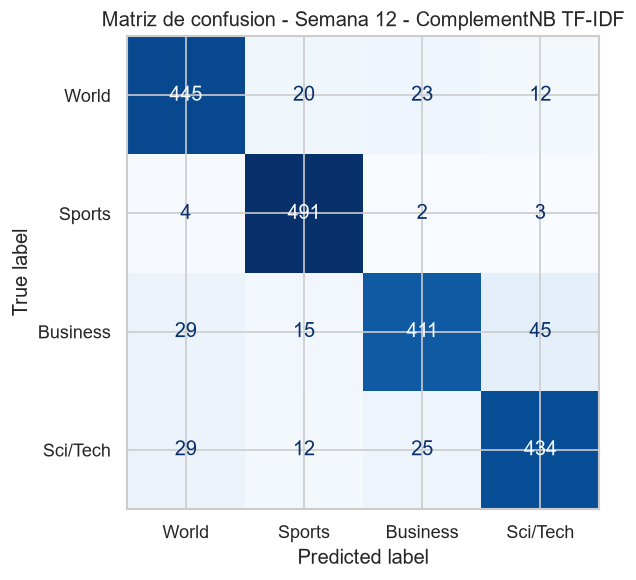

In [23]:
cm = confusion_matrix(y_test, test_pred, labels=LABEL_ORDER)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=TARGET_NAMES).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Matriz de confusion - {best_name}")
plt.tight_layout()
plt.show()

## 10.1 Analisis de errores

Se revisan errores concretos para explicar confusiones. En una sustentacion, esta seccion ayuda a responder por que el modelo falla y como se mitigaria.

In [24]:
error_df = test_model.copy()
error_df["pred_label"] = test_pred
error_df["pred_name"] = error_df["pred_label"].map(LABEL_MAP)
error_df["correcto"] = error_df["label"] == error_df["pred_label"]

errors = error_df[~error_df["correcto"]].copy()
print(f"Errores en test: {len(errors):,} de {len(error_df):,} ({len(errors) / len(error_df) * 100:.2f}%)")

confusion_pairs = (
    errors.groupby(["label_name", "pred_name"])
    .size()
    .reset_index(name="errores")
    .sort_values("errores", ascending=False)
)
display(confusion_pairs.head(10))

display(errors[["label_name", "pred_name", "title_clean", "description_clean"]].head(12))

Errores en test: 219 de 2,000 (10.95%)


,label_name,pred_name,errores
0,Business,Sci/Tech,45
2,Business,World,29
5,Sci/Tech,World,29
3,Sci/Tech,Business,25
9,World,Business,23
11,World,Sports,20
1,Business,Sports,15
4,Sci/Tech,Sports,12
10,World,Sci/Tech,12
8,Sports,World,4


,label_name,pred_name,title_clean,description_clean
0,Sci/Tech,World,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...
9,World,Business,Venezuela Prepares for Chavez Recall Vote,Supporters and rivals warn of possible fraud; ...
14,World,Business,India's Tata expands regional footprint via Na...,AFP - India's Tata Iron and Steel Company Ltd....
21,World,Sports,Jackson Squares Off With Prosecutor,"SANTA MARIA, Calif. - Fans of Michael Jackson ..."
34,Business,Sci/Tech,Yahoo! Ups Ante for Small Businesses,Web giant Yahoo! is gambling that price cuts o...
57,Business,Sci/Tech,"Selling Houston Warts and All, Especially Warts",Descriptions of urban afflictions and images o...
64,Sci/Tech,World,Explorers Find Ancient City in Remote Peru Jun...,Reuters - An ancient walled city complex\inhab...
69,Business,World,Vt. sues over importing drugs,Vermont's Republican governor challenged the B...
75,Sports,Sci/Tech,Glory Comes Amid Empty Seats and Closed Shutters,"HERE in Old Europe, people install shutters ou..."
80,World,Sports,Men Set for Sizzling Duel in 100 Meters,"ATHENS, Greece - The preliminaries in the 100 ..."


# 11. Despliegue reproducible

El artefacto minimo de despliegue es un pipeline scikit-learn serializado con `joblib`. La funcion `predict_topic` documenta el contrato de entrada y salida.

In [25]:
model_path = MODEL_DIR / "ag_news_best_model.joblib"
metadata_path = MODEL_DIR / "ag_news_model_metadata.json"

joblib.dump(best_model, model_path)
metadata = {
    "best_model": best_name,
    "label_map": LABEL_MAP,
    "fast_mode": FAST_MODE,
    "validation_metrics": results_df.iloc[0].to_dict(),
    "test_metrics": test_metrics,
    "dataset": "https://huggingface.co/datasets/sh0416/ag_news",
}
metadata_path.write_text(json.dumps(metadata, indent=2, ensure_ascii=False), encoding="utf-8")

print(f"Modelo guardado en: {model_path.resolve()}")
print(f"Metadata guardada en: {metadata_path.resolve()}")


def predict_topic(title: str, description: str, model=best_model) -> dict:
    text = clean_text(f"{title}. {description}").lower()
    pred = int(model.predict(pd.Series([text]))[0])
    output = {"label": pred, "topic": LABEL_MAP[pred]}
    proba = safe_predict_proba(model, pd.Series([text]))
    if proba is not None:
        output["probabilities"] = {LABEL_MAP[label]: float(proba[0, i]) for i, label in enumerate(LABEL_ORDER)}
    return output

sample_prediction = predict_topic(
    "Central bank signals new interest rate decision",
    "Markets reacted after policymakers discussed inflation, growth and lending conditions.",
)
sample_prediction

Modelo guardado en: C:\Users\ASUS\Documents\Codex\2026-06-09\jhadir08-mineria-de-datos-https-github\Mineria-de-Datos\PMD2_AG_News\artifacts\models\ag_news_best_model.joblib
Metadata guardada en: C:\Users\ASUS\Documents\Codex\2026-06-09\jhadir08-mineria-de-datos-https-github\Mineria-de-Datos\PMD2_AG_News\artifacts\models\ag_news_model_metadata.json


{'label': 3,
 'topic': 'Business',
 'probabilities': {'World': 0.08360902045456305,
  'Sports': 0.050956445028084975,
  'Business': 0.795930409200143,
  'Sci/Tech': 0.06950412531720838}}

# 12. Conclusiones gerenciales

**Decision recomendada.** Usar el mejor pipeline validado como clasificador inicial de noticias para enrutar contenido a equipos editoriales. La decision debe apoyarse en `F1 macro`, no solo en accuracy, porque se requiere desempeno equilibrado en las cuatro categorias.

**Hallazgo principal.** En clasificacion de noticias, los modelos lineales y Naive Bayes con TF-IDF suelen ser muy competitivos. Los modelos mas complejos - boosting, MLP y ensambles - solo justifican su costo si superan claramente el F1 macro del baseline.

**Valor para negocio.** El sistema reduce clasificacion manual repetitiva y permite priorizar revision humana en los casos de baja confianza o en pares de clases con mayor confusion, por ejemplo `Business` frente a `Sci/Tech`.

**Limitaciones.** AG News esta en ingles y tiene categorias generales. No debe usarse directamente para noticias en espanol sin reentrenamiento. La evaluacion no mide sesgos editoriales ni actualidad temporal. El pipeline clasifica textos cortos; noticias largas pueden requerir truncamiento o resumen.

**Siguiente iteracion CRISP-DM.** Si el modelo se usa en produccion, recolectar errores reales de analistas, crear una cola de revision para predicciones de baja confianza, recalibrar probabilidades y evaluar drift por fuente, fecha y tema.

# 13. Referencias APA 7

- Hugging Face. (s. f.). *sh0416/ag_news dataset*. https://huggingface.co/datasets/sh0416/ag_news
- Zhang, X., Zhao, J., & LeCun, Y. (2015). Character-level convolutional networks for text classification. *Advances in Neural Information Processing Systems, 28*.
- Scikit-learn developers. (s. f.). *Scikit-learn: Machine learning in Python*. https://scikit-learn.org/stable/
- Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., & Wirth, R. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS.